Overview:
In this dataset we can predict whether a loan is default or be approved. This is a classification problem and this is supervised learning as the dataset is labled data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Data Analysis

In [2]:
df = pd.read_csv('loan_data.csv')

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
df.tail()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
df.shape

(45000, 14)

In [7]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


The applicants average age is 28, with a minimum age of 20 and a maximum age of 144, which is an outlier. The greatest experience of 125 years indicates the presence of extreme outliers, whereas the mean employment experience is 5.4 years and the median is 4 years. In terms of income, 75% of applicants make 95,789 or less, while the maximum value is an extreme outlier at 7.2 million. The average and minimum values are very similar.

In [8]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [9]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [10]:
df.nunique()

person_age                           60
person_gender                         2
person_education                      5
person_income                     33989
person_emp_exp                       63
person_home_ownership                 4
loan_amnt                          4483
loan_intent                           6
loan_int_rate                      1302
loan_percent_income                  64
cb_person_cred_hist_length           29
credit_score                        340
previous_loan_defaults_on_file        2
loan_status                           2
dtype: int64

Here by nununique we find the unique distinct values.

In [11]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

Here 0 means non default and 1 means default.

In [12]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

In [13]:
df['person_home_ownership'].value_counts()

person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

In [14]:
df['person_gender'].value_counts()

person_gender
male      24841
female    20159
Name: count, dtype: int64

#Exploratory Data Analysis.

In [15]:
import matplotlib.pyplot as plt

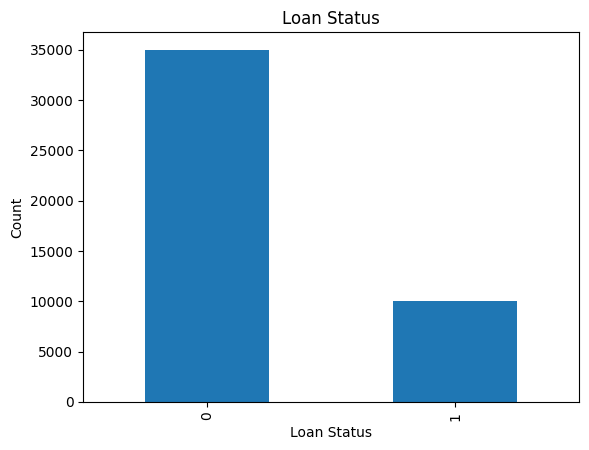

In [16]:
#Barplot for loan status

plt.figure()
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

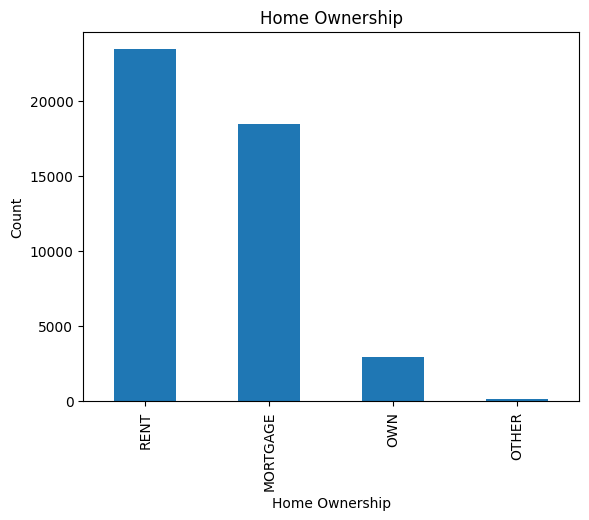

In [17]:
#Barplot for home ownership

plt.figure()
df["person_home_ownership"].value_counts().plot(kind='bar')
plt.title("Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Count")
plt.show()

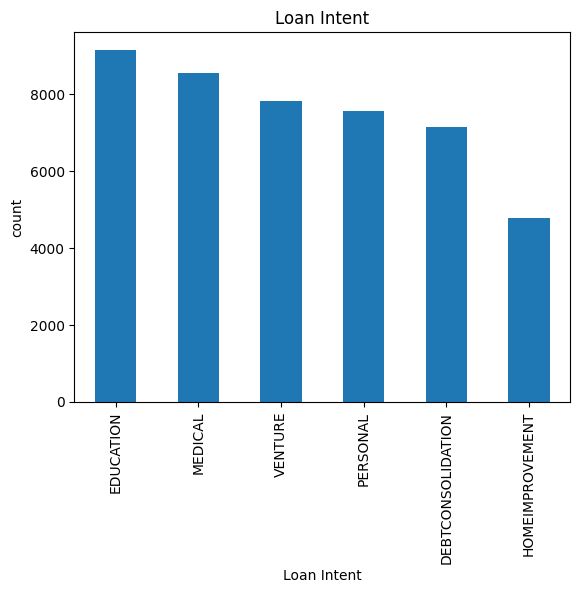

In [18]:
#Barplot for loan intent

plt.figure()
df["loan_intent"].value_counts().plot(kind = 'bar')
plt.title("Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("count")
plt.show()

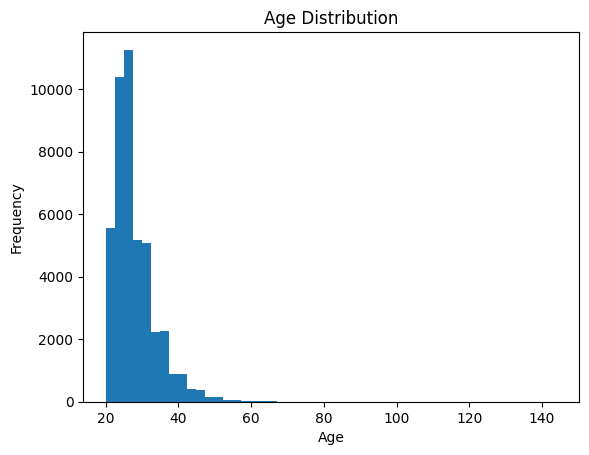

In [19]:
#Histogram of age distribution

plt.figure()
plt.hist(df["person_age"], bins = 50)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

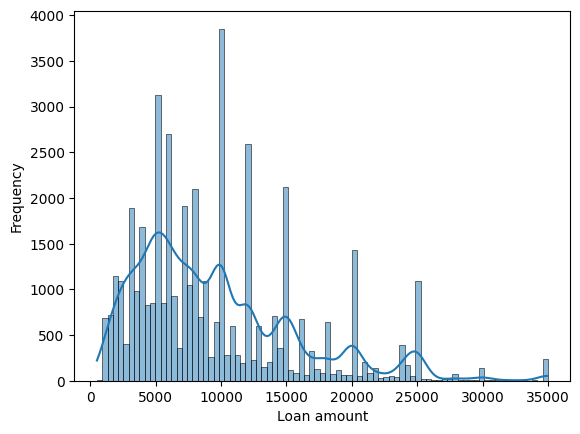

In [20]:
#Histogram for loan amount

sns.histplot(df['loan_amnt'], kde=True)
plt.xlabel("Loan amount")
plt.ylabel("Frequency")
plt.show()

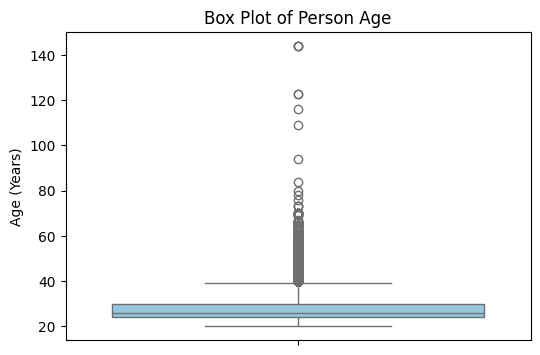

In [21]:
# Box Plot for person_age

plt.figure(figsize=(6, 4))
sns.boxplot(y=df['person_age'], color='skyblue')
plt.title("Box Plot of Person Age")
plt.ylabel("Age (Years)")
plt.show()

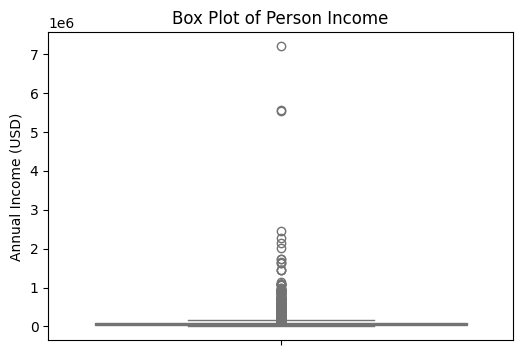

In [22]:
# Box Plot for person_income
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['person_income'], color='lightgreen')
plt.title("Box Plot of Person Income")
plt.ylabel("Annual Income (USD)")
plt.show()

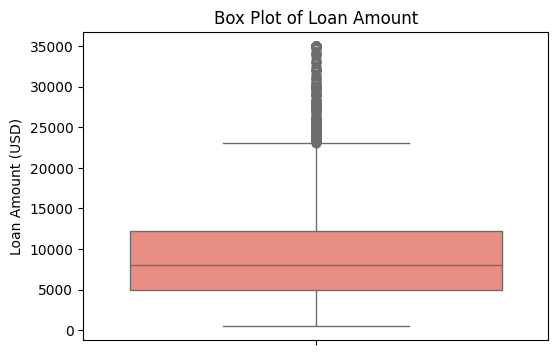

In [23]:
# Box Plot for loan_amnt
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['loan_amnt'], color='salmon')
plt.title("Box Plot of Loan Amount")
plt.ylabel("Loan Amount (USD)")
plt.show()

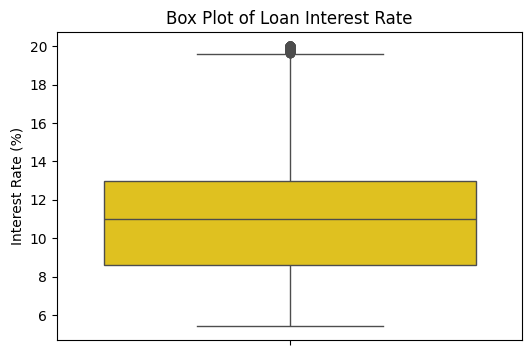

In [24]:
# Box Plot for loan_int_rate

plt.figure(figsize=(6, 4))
sns.boxplot(y=df['loan_int_rate'], color='gold')
plt.title("Box Plot of Loan Interest Rate")
plt.ylabel("Interest Rate (%)")
plt.show()

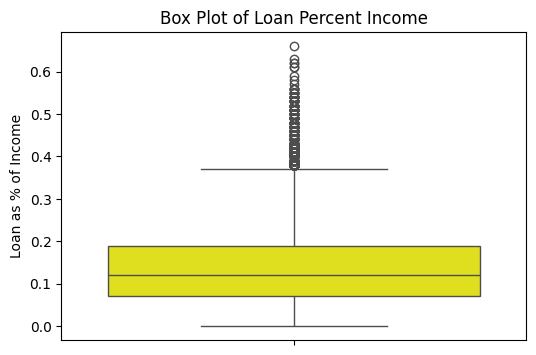

In [25]:
# Box Plot for loan_percent_income

plt.figure(figsize=(6, 4))
sns.boxplot(y=df['loan_percent_income'], color='yellow')
plt.title("Box Plot of Loan Percent Income")
plt.ylabel("Loan as % of Income")
plt.show()

#Data Cleaning

In [26]:
#Remove impossible Ages entries
df = df[df['person_age'] < 90]

#Remove impossible Employment Experience (Exp cannot be > Age)
df = df[df['person_emp_exp'] < df['person_age']]

#Cap extreme Income at the 99th percentile
# This prevents the model from being distracted by multi-millionaire outliers
income_cap = df['person_income'].quantile(0.99)
df['person_income'] = df['person_income'].clip(upper=income_cap)

# feature engineering Create Loan-to-Income Ratio
df['loan_to_income_ratio'] = df['loan_amnt'] / df['person_income']

print(f"Data cleaning complete. New shape: {df.shape}")

Data cleaning complete. New shape: (44992, 15)


In [27]:
df.shape

(44992, 15)

In [28]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status',
       'loan_to_income_ratio'],
      dtype='object')

In [31]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_to_income_ratio
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,0.486462
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,0.081420
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,0.442193
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1,0.438855
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1,0.529221


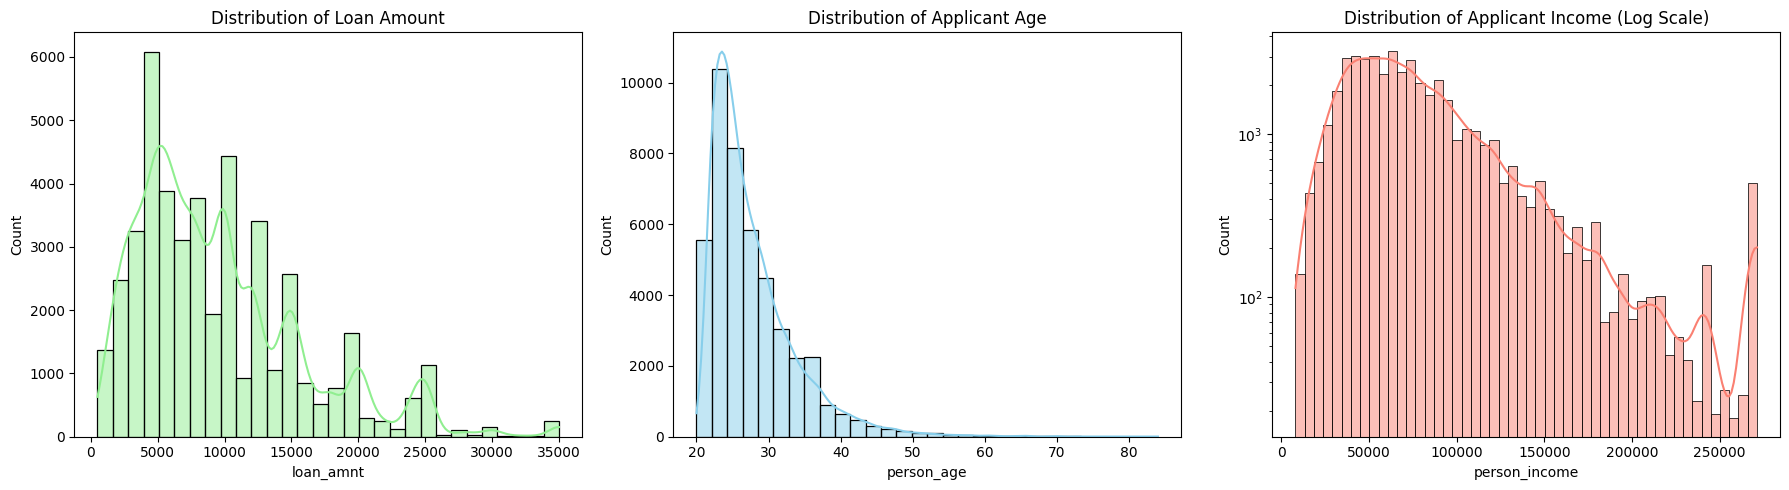

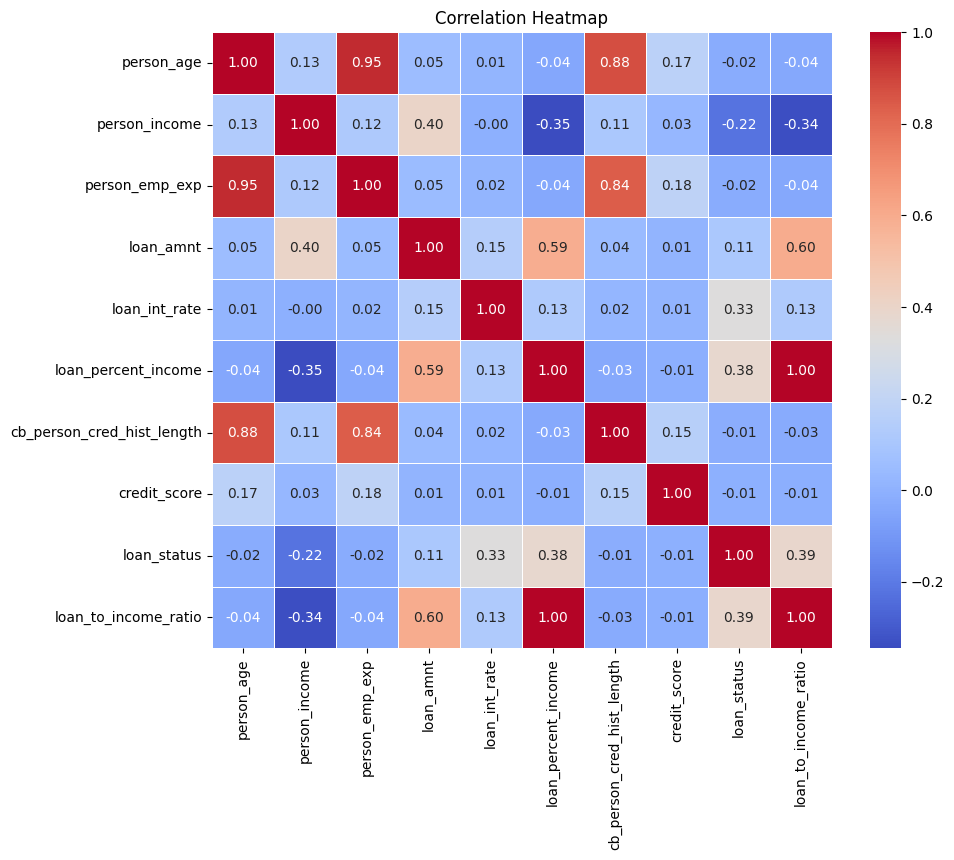

In [34]:
plt.figure(figsize=(18, 5))

# 1. Loan Amount Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['loan_amnt'], bins=30, kde=True, color='lightgreen')
plt.title('Distribution of Loan Amount')

# 2. Age Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['person_age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Applicant Age')

# 3. Income Distribution (Log Scale for readability)
plt.subplot(1, 3, 3)
sns.histplot(df['person_income'], bins=50, kde=True, color='salmon')
plt.yscale('log')
plt.title('Distribution of Applicant Income (Log Scale)')

plt.tight_layout()
plt.show()

# Correlation Heatmap for numeric variables
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()